In [21]:
import os

import pandas as pd
import numpy as np

from scipy.stats import spearmanr
from scipy.stats import pearsonr

import itertools

import seaborn as sns

from scipy import stats

from tqdm import tqdm

import matplotlib.pyplot as plt

from matplotlib_venn import venn2

import warnings
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)

In [22]:
import matplotlib.pyplot as plt
from matplotlib import rc

# set style
plt.style.use('seaborn-v0_8-paper')

# set sizes
SMALL_SIZE = 5
MEDIUM_SIZE = 6
BIGGER_SIZE = 8

rc('font', size=MEDIUM_SIZE)          # controls default text sizes
rc('axes', titlesize=MEDIUM_SIZE)     # fontsize of the axes title
rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
rc('xtick', labelsize=MEDIUM_SIZE)    # fontsize of the tick labels
rc('ytick', labelsize=MEDIUM_SIZE)    # fontsize of the tick labels
rc('legend', fontsize=MEDIUM_SIZE)    # legend fontsize
rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

# set font
rc('font', **{'family':'serif','serif':['Arial']})
rc('svg', **{'fonttype':'none'})

# one more change to axes and tick widths
rc('axes', **{'linewidth': 0.5, 'labelpad': 2.5})

rc('xtick', **{'major.width': 0.5, 'minor.width': 0.5, 'major.pad': 2.5})
rc('ytick', **{'major.width': 0.5, 'minor.width': 0.5, 'major.pad': 2.5})

In [23]:
from matplotlib.colors import LinearSegmentedColormap

color_min    = "green"
color_center = "black"
color_max    = "red"
cmap = LinearSegmentedColormap.from_list(
    "cmap_name",
    [color_min, color_center, color_max]
)

In [4]:
path_out_dir = 'figures'

In [50]:
# normalized, downsampled (same filtering as dataset integration)
# this is used for histogram plots
path_pq_wt_1 = '../preprocessing/wt_tko/transcript_counts/wt_rep1.filtered.samecg.downsampled.normalized.gm10000.parquet.gz'
path_pq_tko_1 = '../preprocessing/wt_tko/transcript_counts/tko_rep1.filtered.samecg.downsampled.normalized.gm10000.parquet.gz'

path_pq_wt_2 = '../preprocessing/wt_tko/transcript_counts/wt_rep2.filtered.samecg.downsampled.normalized.gm10000.parquet.gz'
path_pq_tko_2 = '../preprocessing/wt_tko/transcript_counts/tko_rep2.filtered.samecg.downsampled.normalized.gm10000.parquet.gz'

path_pq_wt_dko_2 = '../preprocessing/wt_dko/transcript_counts/wt_rep2.filtered.samecg.downsampled.normalized.gm10000.parquet.gz'
path_pq_dko_2 = '../preprocessing/wt_dko/transcript_counts/dko_rep2.filtered.samecg.downsampled.normalized.gm10000.parquet.gz'

In [5]:
# downsampled (same filtering as dataset integration)
path_pq_wt_1 = '../preprocessing/wt_tko/transcript_counts/wt_rep1.filtered.samecg.downsampled.parquet.gz'
path_pq_tko_1 = '../preprocessing/wt_tko/transcript_counts/tko_rep1.filtered.samecg.downsampled.parquet.gz'

path_pq_wt_2 = '../preprocessing/wt_tko/transcript_counts/wt_rep2.filtered.samecg.downsampled.parquet.gz'
path_pq_tko_2 = '../preprocessing/wt_tko/transcript_counts/tko_rep2.filtered.samecg.downsampled.parquet.gz'

path_pq_wt_dko_2 = '../preprocessing/wt_dko/transcript_counts/wt_rep2.filtered.samecg.downsampled.parquet.gz'
path_pq_dko_2 = '../preprocessing/wt_dko/transcript_counts/dko_rep2.filtered.samecg.downsampled.parquet.gz'

In [6]:
def corrfunc(x, y, **kws):
    # Convert to numpy arrays
    x = np.asarray(x)
    y = np.asarray(y)
    
    # Mask out NaN or inf values
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]
    
    ax = plt.gca()
    if len(x) > 1:  # Need at least 2 points for correlation
        r, p = pearsonr(x, y)
        #r, p = spearmanr(x, y)
        ax.annotate(f"ρ = {r:.2f}", xy=(.1, .85), xycoords=ax.transAxes, fontsize=8)
    else:
        ax.annotate("ρ = NaN\np = NaN", xy=(.1, .85), xycoords=ax.transAxes, fontsize=8)

In [7]:
def get_stats(df, suffix=''):
    # Transpose so genes are rows and cells are columns
    df = df.T

    df_stats = pd.DataFrame(index=df.index)
    df_stats['gene'] = df_stats.index
    
    # Basic stats across all cells
    df_stats['mean'] = df.mean(axis=1)
    df_stats['var'] = df.var(axis=1)
    df_stats['std'] = df.std(axis=1)
    
    # Nonzero mask
    nonzero_mask = df != 0
    
    # Stats on nonzero values only
    nonzero_mean = df.where(nonzero_mask).mean(axis=1)
    nonzero_var = df.where(nonzero_mask).var(axis=1)
    nonzero_std = df.where(nonzero_mask).std(axis=1)

    # Dispersion and coefficient of variation (nonzero only)
    df_stats['dispersion_nonzero'] = nonzero_var / nonzero_mean
    df_stats['coeff_var_nonzero'] = nonzero_std / nonzero_mean

    # Dispersion and CV (all cells, for comparison)
    df_stats['dispersion'] = df_stats['var'] / df_stats['mean']
    df_stats['coeff_var'] = df_stats['std'] / df_stats['mean']

    # Log2 of numeric columns (skip non-positive values)
    for column in df_stats.select_dtypes(include=[np.number]).columns:
        with np.errstate(divide='ignore', invalid='ignore'):
            df_stats[f'log_{column}'] = np.log2(df_stats[column].where(df_stats[column] > 0))

    # Zero / nonzero ratios
    zero_counts = (df == 0).sum(axis=1)
    nonzero_counts = (df != 0).sum(axis=1)
    total_counts = zero_counts + nonzero_counts

    df_stats['zero_ratio'] = zero_counts / total_counts
    df_stats['nonzero_ratio'] = nonzero_counts / total_counts

    df_stats['treatment'] = suffix

    return df_stats

In [8]:
names = ['WT rep1', 'WT rep2', 'TKO rep1', 'TKO rep2', 'DKO rep2']
names_tko = ['WT', 'TKO']
names_dko = ['WT Rep2', 'DKO Rep2']

In [9]:
df_counts_wt_1 = pd.read_parquet(path_pq_wt_1)
df_counts_wt_1.index = [i for i, cell_name in enumerate(df_counts_wt_1.index)]

df_counts_tko_1 = pd.read_parquet(path_pq_tko_1)
df_counts_tko_1.index = [i for i, cell_name in enumerate(df_counts_tko_1.index)]

df_counts_wt_2 = pd.read_parquet(path_pq_wt_2)
df_counts_wt_2.index = [i for i, cell_name in enumerate(df_counts_wt_2.index)]

df_counts_tko_2 = pd.read_parquet(path_pq_tko_2)
df_counts_tko_2.index = [i for i, cell_name in enumerate(df_counts_tko_2.index)]



df_counts_dko_2 = pd.read_parquet(path_pq_dko_2)
df_counts_dko_2.index = [i for i, cell_name in enumerate(df_counts_dko_2.index)]

df_counts_wt_dko_2 = pd.read_parquet(path_pq_wt_dko_2)
df_counts_wt_dko_2.index = [i for i, cell_name in enumerate(df_counts_wt_dko_2.index)]

# combine
df_counts_wt = pd.concat([df_counts_wt_1, df_counts_wt_2], ignore_index=True)
df_counts_tko = pd.concat([df_counts_tko_1, df_counts_tko_2], ignore_index=True)

df_counts_dko = pd.concat([df_counts_dko_2], ignore_index=True)
df_counts_wt_dko = pd.concat([df_counts_wt_dko_2], ignore_index=True)


# in order to avoid NAs later due to genes dropped from the dataframes, we assign 0's
all_genes = set(df_counts_wt.columns) | set(df_counts_tko.columns) | set(df_counts_dko.columns) | set(df_counts_wt_dko.columns)

df_counts_wt[list(all_genes - set(df_counts_wt.columns))] = 0.0
df_counts_tko[list(all_genes - set(df_counts_tko.columns))] = 0.0
df_counts_dko[list(all_genes - set(df_counts_dko.columns))] = 0.0
df_counts_wt_dko[list(all_genes - set(df_counts_wt_dko.columns))] = 0.0

dfs_tko = [df_counts_wt, df_counts_tko]
dfs_dko = [df_counts_wt_dko, df_counts_dko]



In [10]:
stats_tko = get_stats(df_counts_tko, suffix='TKO')
stats_wt = get_stats(df_counts_wt, suffix='WT')
stats_dko = get_stats(df_counts_dko, suffix='DKO')
stats_wt_dko = get_stats(df_counts_wt_dko, suffix='WT_DKONORM')

print(stats_wt)

                        gene      mean       var       std  \
SERHL2                SERHL2  0.007597  0.007541  0.086838   
RP11-645C24.5  RP11-645C24.5  0.000883  0.000883  0.029711   
METTL10              METTL10  0.784982  1.088412  1.043270   
NDUFA9                NDUFA9  1.294523  2.176362  1.475250   
RP11-550F7.1    RP11-550F7.1  0.002473  0.002468  0.049677   
...                      ...       ...       ...       ...   
RP11-114B7.6    RP11-114B7.6  0.000000  0.000000  0.000000   
HTR3E-AS1          HTR3E-AS1  0.000000  0.000000  0.000000   
AF186192.6        AF186192.6  0.000000  0.000000  0.000000   
GNAT1                  GNAT1  0.000000  0.000000  0.000000   
AC073071.1        AC073071.1  0.000000  0.000000  0.000000   

               dispersion_nonzero  coeff_var_nonzero  dispersion  coeff_var  \
SERHL2                   0.000000           0.000000    0.992578  11.430266   
RP11-645C24.5            0.000000           0.000000    0.999293  33.633315   
METTL10           

In [11]:
# get promoter types
# promoter
intersection_type = 'promoter'
#intersection_type = 'intragenic_limit'
#intersection_type = 'intragenic'

promoter_size = 2000 #this exists already in the input file
promoter_extension = 8000 #this is added during this script
path_promoter_type_bed = f'../basics/{intersection_type}_basics_ratio0_{promoter_size}.bed'

# mean_1 will be tko or dko

column_names = ['chrom', 'start', 'stop', 'length', 'strand', 'gene', 'Ratio Bivalent',
       'Ratio H3K27me3', 'Ratio H3K4me3', 'MeanOverall_dko', 'Mean1_dko',
       'Mean2_dko', 'MeanFC_dko', 'MeanLog2FC_dko', 'ProbDiffMean_dko',
       'ResultDiffMean_dko', 'DispOverall_dko', 'Disp1_dko', 'Disp2_dko',
       'DispFC_dko', 'DispLog2FC_dko', 'ProbDiffDisp_dko',
       'ResultDiffDisp_dko', 'MeanOverall_tko', 'Mean1_tko', 'Mean2_tko',
       'MeanFC_tko', 'MeanLog2FC_tko', 'ProbDiffMean_tko',
       'ResultDiffMean_tko', 'DispOverall_tko', 'Disp1_tko', 'Disp2_tko',
       'DispFC_tko', 'DispLog2FC_tko', 'ProbDiffDisp_tko',
       'ResultDiffDisp_tko', 'Promoter Class']

df_promoter_type = pd.read_csv(path_promoter_type_bed, sep='\t', header=None, names=column_names)

df_promoter_type.rename(columns={'chrom': '#chrom'}, inplace=True)

if intersection_type == 'promoter':
    df_promoter_type['start'] = df_promoter_type['start'] - promoter_extension
    df_promoter_type['stop'] = df_promoter_type['stop'] + promoter_extension

df_promoter_type.index = df_promoter_type['gene']

print(df_promoter_type)

         #chrom      start       stop  length strand      gene  \
gene                                                             
A1BG      chr19   58854858   58874858    8309      -      A1BG   
A1BG-AS1  chr19   58853336   58873336    3213      +  A1BG-AS1   
A1CF      chr10   52635387   52655387   86218      -      A1CF   
A2M       chr12    9258825    9278825   48521      -       A2M   
A2M-AS1   chr12    9207773    9227773    2878      +   A2M-AS1   
...         ...        ...        ...     ...    ...       ...   
ZYG11A     chr1   53298432   53318432   52235      +    ZYG11A   
ZYG11B     chr1   53182125   53202125  100883      +    ZYG11B   
ZYX        chr7  143068438  143088438    9766      +       ZYX   
ZZEF1     chr17    4036324    4056324  138585      -     ZZEF1   
ZZZ3       chr1   78138343   78158343  120242      -      ZZZ3   

          Ratio Bivalent  Ratio H3K27me3  Ratio H3K4me3  MeanOverall_dko  ...  \
gene                                                        

In [54]:
# merge
def nb_zero_prob(log2_mean, r):
    mu = 2 ** log2_mean
    return (r / (r + mu)) ** r

def invert_nb_zero_prob(zero_ratio, r):    
    mu = r * (zero_ratio ** (-1/r) - 1)
    return np.log2(mu)

def make_expected_zero_ratio(df, x, y, n_cells, depth):
    r = np.sqrt(depth / n_cells)
    df[f'expected_{y}'] = nb_zero_prob(df[x], r)
    df[f'residual_{y}'] = df[y] - df[f'expected_{y}']

def assign_category(df, column, column_new, cutoffs):
    conditions = [
                    (df[column] > cutoffs[1]),
                    (df[column] < cutoffs[0]),
                    (df[column] <= cutoffs[1]) & (df_merged[column] >= cutoffs[0])
                    ]
    
    values = ['Increase', 'Decrease', 'No Change']
    df[column_new] = np.select(conditions, values)

def assign_category_bin_by_class(df, column, column_new, num_bins):
    # create categories with equally sized bins for each promoter class
    df_list = []
    for pclass, df_filt in df.groupby("Promoter Class"):
        df_filt = df_filt.copy()
        df_filt[column_new] = pd.qcut(
            df_filt[column].rank(method='first'),
            q=num_bins,
            labels=[str(i) for i in range(num_bins)]
        ).astype(str)
        df_list.append(df_filt)

    return pd.concat(df_list, ignore_index=True)

stats_wt_numeric = stats_wt.select_dtypes(include='number')
stats_tko_numeric = stats_tko.select_dtypes(include='number')
stats_dko_numeric = stats_dko.select_dtypes(include='number')
stats_wt_dko_numeric = stats_wt_dko.select_dtypes(include='number')

df_diff_tko = stats_tko_numeric - stats_wt_numeric
df_diff_tko = df_diff_tko.add_suffix('_diff_tko')

df_diff_dko = stats_dko_numeric - stats_wt_dko_numeric
df_diff_dko = df_diff_dko.add_suffix('_diff_dko')

stats_wt_numeric = stats_wt_numeric.add_suffix('_wt')
stats_tko_numeric = stats_tko_numeric.add_suffix('_tko')
stats_dko_numeric = stats_dko_numeric.add_suffix('_dko')
stats_wt_dko_numeric = stats_wt_dko_numeric.add_suffix('_wt_dkonorm')

# need to be careful with dropna in a combined df, since some genes are not expressed in dko
# need to set a zero for those I guess?
df_merged = pd.concat([df_promoter_type, stats_wt_numeric, stats_tko_numeric, stats_dko_numeric, stats_wt_dko_numeric, df_diff_tko, df_diff_dko], axis=1)
df_merged.dropna(subset=['start', 'stop'], inplace=True)

n_cells_wt = len(df_counts_wt.index)
n_cells_wt_dko = len(df_counts_wt_dko.index)
n_cells_tko = len(df_counts_tko.index)
n_cells_dko = len(df_counts_dko.index)

sum_wt = df_counts_wt.sum().sum()
sum_wt_dko = df_counts_wt_dko.sum().sum()
sum_tko = df_counts_tko.sum().sum()
sum_dko = df_counts_dko.sum().sum()

depth_wt = sum_wt / n_cells_wt
depth_wt_dko = sum_wt_dko / n_cells_wt_dko
depth_tko = sum_tko / n_cells_tko
depth_dko = sum_dko / n_cells_dko

make_expected_zero_ratio(df_merged, 'log_mean_wt', 'zero_ratio_wt', n_cells_wt, depth_wt)
make_expected_zero_ratio(df_merged, 'log_mean_tko', 'zero_ratio_tko', n_cells_tko, depth_tko)
make_expected_zero_ratio(df_merged, 'log_mean_wt_dkonorm', 'zero_ratio_wt_dkonorm', n_cells_wt_dko, depth_wt_dko)
make_expected_zero_ratio(df_merged, 'log_mean_dko', 'zero_ratio_dko', n_cells_dko, depth_dko)

df_merged['residual_diff_tko'] = df_merged['residual_zero_ratio_tko'] - df_merged['residual_zero_ratio_wt']
df_merged['residual_diff_dko'] = df_merged['residual_zero_ratio_dko'] - df_merged['residual_zero_ratio_wt_dkonorm']

# assign na for dispersion change for exclusion from testing
'''
df_merged['DispLog2FC_tko'] = np.where(
    (df_merged['ResultDiffDisp_tko'] == 'ExcludedFromTesting'),
    np.nan,
    df_merged['DispLog2FC_tko']
)

df_merged['DispLog2FC_dko'] = np.where(
    (df_merged['ResultDiffDisp_dko'] == 'ExcludedFromTesting'),
    np.nan,
    df_merged['DispLog2FC_dko']
)
'''

# before assigning categories, we shuffle
df_merged = df_merged.sample(frac=1)

num_bins = 10
cats = [
    ['zero_ratio_diff_tko', 'TKO ZR Change Class', [-0.2, 0.2], num_bins],
    ['zero_ratio_diff_dko', 'DKO ZR Change Class', [-0.1, 0.1], num_bins],
    ['MeanLog2FC_tko', 'TKO MeanFC Class', [-1, 1], num_bins],
    ['MeanLog2FC_dko', 'DKO MeanFC Class', [-1, 1], num_bins],
    ['DispLog2FC_tko', 'TKO DispFC Class', [0.5, 1.5], num_bins],
    ['DispLog2FC_dko', 'DKO DispFC Class', [-1, 1], num_bins],
    ['log_dispersion_nonzero_diff_tko', 'TKO DispNonZeroFC Class', [-1,1], num_bins],
    ['log_dispersion_nonzero_diff_dko', 'DKO DispNonZeroFC Class', [-1,1], num_bins],
    ['residual_diff_tko', 'TKO ZR Residual Class', [-0.02,0.02], num_bins],
    ['residual_diff_dko', 'DKO ZR Residual Class', [-0.02,0.02], num_bins],
    ['log_mean_wt', 'WT Mean Class', [-0.02, 0.02], num_bins],
]

# make selection for bins or categories
for cat in cats:
    assign_category(df_merged, cat[0], cat[1], cat[2])
    #df_merged = assign_category_bin_by_class(df_merged, cat[0], cat[1], cat[3])
    df_merged[f'Combined {cat[1]}'] = df_merged['Promoter Class'] + ' ' + df_merged[cat[1]]

df_merged['start'] = df_merged['start'].astype(int)
df_merged['stop'] = df_merged['stop'].astype(int)

print(len(df_merged.index))


TKO/WT Zero Ratio Standard Deviation: 0.095993354811164, Cutoff: 0.2
DKO/WT Zero Standard Deviation: 0.06539901040492277, Cutoff: 0.1
TKO L2FCDisp mean: 0.8238718385367392
TKO L2FCDisp std: 1.1094794012888751
16394


In [17]:
# Print some values of genes

genes = ['NR2F1', 'NR2F2', 'POU5F1', 'GBX2', 'PAX6']

print(df_merged.loc[df_merged['gene'].isin(genes)][['residual_diff_tko', 'DispLog2FC_tko']])

        residual_diff_tko  DispLog2FC_tko
NR2F2            0.082559          -7.225
GBX2             0.086138          -3.497
PAX6             0.051861          -4.643
POU5F1           0.583780           7.177
NR2F1            0.224562          -6.957


2.664707818501537e-18 2.3393613793103447 1.5926772908366533


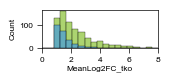

0.009251478986198722 -1.9577124324324324 -1.826032258064516


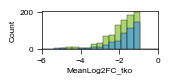

In [18]:
# Histograms of Log2FC(Mean)

df_bivalent = df_merged.loc[df_merged['Promoter Class'] == 'Bivalent']

bins_increase = np.linspace(0,8,20)

fig, ax = plt.subplots(figsize=(1.5,0.5))
df_bivalent_tko = df_bivalent.loc[df_bivalent['TKO MeanFC Class'] == 'Increase']
sns.histplot(data=df_bivalent_tko, x='MeanLog2FC_tko', ax=ax, bins=bins_increase, color='#90c640')

df_bivalent_dko = df_bivalent.loc[df_bivalent['DKO MeanFC Class'] == 'Increase']
sns.histplot(data=df_bivalent_dko, x='MeanLog2FC_dko', ax=ax, bins=bins_increase, color='#4b9ed7')

res = stats.ttest_ind(df_bivalent_tko['MeanLog2FC_tko'], df_bivalent_dko['MeanLog2FC_dko'])
print(res.pvalue, np.mean(df_bivalent_tko['MeanLog2FC_tko']), np.mean(df_bivalent_dko['MeanLog2FC_dko']))

#plt.xlim([-6, 0])
plt.xlim([0, 8])

plt.savefig('figures/tko_dko_mean_increase.svg')

plt.show()


bins_decrease = np.linspace(-6,0,20)

fig, ax = plt.subplots(figsize=(1.5,0.5))
df_bivalent_tko = df_bivalent.loc[df_bivalent['TKO MeanFC Class'] == 'Decrease']

sns.histplot(data=df_bivalent_tko, x='MeanLog2FC_tko', ax=ax, bins=bins_decrease, color='#90c640')

df_bivalent_dko = df_bivalent.loc[df_bivalent['DKO MeanFC Class'] == 'Decrease']
sns.histplot(data=df_bivalent_dko, x='MeanLog2FC_dko', ax=ax, bins=bins_decrease, color='#4b9ed7')

res = stats.ttest_ind(df_bivalent_tko['MeanLog2FC_tko'], df_bivalent_dko['MeanLog2FC_dko'])
print(res.pvalue, np.mean(df_bivalent_tko['MeanLog2FC_tko']), np.mean(df_bivalent_dko['MeanLog2FC_dko']))

plt.xlim([-6, 0])
#plt.xlim([0, 8])

plt.savefig('figures/tko_dko_mean_decrease.svg')

plt.show()

In [56]:
# output bed file for downstream analysis
path_root_bed = f'/home/data/Shared/shared_datasets/sc_rna_seq/nlaszik/tko_zero_ratio/bed_{intersection_type}_{promoter_size}_{promoter_extension}'

os.makedirs(path_root_bed, exist_ok=True)

path_out = f'{path_root_bed}/stats_cutoffs.bed'
#path_out = f'{path_root_bed}/stats_bin.bed'

print(path_out)
df_merged.to_csv(path_out, sep='\t', index=False)

/home/data/Shared/shared_datasets/sc_rna_seq/nlaszik/tko_zero_ratio/bed_promoter_2000_8000/tko_zero_ratio_cutoffs.bed


PermissionError: [Errno 13] Permission denied: '/home/data/Shared/shared_datasets/sc_rna_seq/nlaszik/tko_zero_ratio/bed_promoter_2000_8000/tko_zero_ratio_cutoffs.bed'

In [55]:
def downsample_to_match(df, promoter_type, var_pre_filter, val_pre_filter, var_to_separate, val_to_separate, var_to_match, i_bootstrap):

    df_filt = df.loc[df['Promoter Class'] == promoter_type]

    if var_pre_filter is not None:
        df_filt = df_filt.loc[df_filt[var_pre_filter] == val_pre_filter]
    
    #sns.kdeplot(data=df_filt, x=var_to_match, hue=var_to_separate, common_norm=True)
    #plt.show()
    
    df_source = df_filt.loc[df_filt[var_to_separate] == 'No Change']
    df_target = df_filt.loc[df_filt[var_to_separate] == val_to_separate]
    
    # Create bins based on the combined data range to ensure consistency
    combined_data = pd.concat([df_source[var_to_match], df_target[var_to_match]])
    bin_edges = pd.cut(combined_data, bins=10, retbins=True)[1]
    
    df_sampled_source = pd.DataFrame(columns=df_source.columns)
    df_sampled_target = pd.DataFrame(columns=df_target.columns)
    
    for i in range(len(bin_edges) - 1):
        left, right = bin_edges[i], bin_edges[i + 1]
        
        # Filter both source and target data for the current bin
        source_in_bin = df_source[(df_source[var_to_match] > left) & (df_source[var_to_match] <= right)]
        target_in_bin = df_target[(df_target[var_to_match] > left) & (df_target[var_to_match] <= right)]
        
        n_source = len(source_in_bin)
        n_target = len(target_in_bin)
        
        #print(f"Bin [{left:.2f}, {right:.2f}]: source={n_source}, target={n_target}")
        
        # Downsample whichever has more samples to match the smaller count
        n_samples = min(n_source, n_target)
        
        if n_samples > 0:

            # bootstrap
            sampled_source = source_in_bin.sample(n=n_samples, replace=True)
            sampled_target = target_in_bin.sample(n=n_samples, replace=True)
            
            df_sampled_source = pd.concat([df_sampled_source, sampled_source])
            df_sampled_target = pd.concat([df_sampled_target, sampled_target])

    # Combine the balanced samples
    df_sampled = pd.concat([df_sampled_source, df_sampled_target])

    if i_bootstrap == 0:
        print(f"Original counts: source={len(df_source)}, target={len(df_target)}")
        print(f"Sampled counts: source={len(df_sampled_source)}, target={len(df_sampled_target)}")
        print()
    
    # Visualize the result
    #sns.kdeplot(data=df_sampled, x='log_mean_wt', hue=var_to_separate, common_norm=True)
    #plt.title('After Matching Distributions')
    #plt.show()

    return df_sampled

promoter_types = ['H3K4me3', 'Bivalent']
vars_prefilt = [None, 'DKO ZR Residual Class', 'TKO ZR Residual Class', 'TKO MeanFC Class']
vals_prefilt = ['Increase', 'No Change', 'Decrease']
vars_to_separate = ['DKO MeanFC Class', 'TKO ZR Residual Class', 'TKO MeanFC Class']
vals_to_separate = ['Increase', 'Decrease']

all_lists = [promoter_types, vars_prefilt, vals_prefilt, vars_to_separate, vals_to_separate]

# Generate all combinations (Cartesian product)
combinations_iterator = itertools.product(*all_lists)

# Convert the iterator to a list of tuples
all_combinations = list(combinations_iterator)

path_root_bed = f'/home/data/Shared/shared_datasets/sc_rna_seq/nlaszik/tko_zero_ratio/bed_{intersection_type}_{promoter_size}_{promoter_extension}/filter'
os.makedirs(path_root_bed, exist_ok=True)

num_boostraps = 10

for combination in all_combinations:

    promoter_type = combination[0]
    var_prefilt = combination[1]
    val_prefilt = combination[2]
    var_to_separate = combination[3]
    val_to_separate = combination[4]

    experiment_sep = var_to_separate.lower()[0:3]
    
    if var_prefilt is not None:
        
        experiment_prefilt = var_prefilt.lower()[0:3]
        if 'Mean' in var_prefilt:
            name_var_prefilt = 'mean'
        else:
            name_var_prefilt = 'res'

        name_val_prefilt = val_prefilt.lower().replace(' ', '')[0:3]
        
    else:
        experiment_prefilt = experiment_sep
        name_var_prefilt = 'none'
        name_val_prefilt = ''

    if promoter_type == 'Bivalent':
        promoter_type_short = 'biv'
    else:
        promoter_type_short = 'k4'

    if 'Mean' in var_to_separate:
        name_var_sep = 'mean'
    else:
        name_var_sep = 'res'

    name_val_sep = val_to_separate.lower()[0:3]

    # don't run filtering for comparisons that make no sense
    if experiment_prefilt != experiment_sep:
        # tko vs. dko
        continue
    if name_var_sep == name_var_prefilt:
        # don't filter on the same variable we are trying to match
        continue
    if name_var_prefilt == 'res' and name_val_prefilt != 'noc':
        # for residual filtering, we only care about no change
        continue
    if name_var_prefilt == 'none' and name_val_prefilt != '':
        # for no fitlering, only run once
        continue
    if name_var_sep == 'res' and name_val_sep != 'inc':
        continue

    for i_bootstrap in range(num_boostraps):
        
        path_out = f'{path_root_bed}/{experiment_sep}_{promoter_type_short}_filt{name_var_prefilt}{name_val_prefilt}_match{name_var_sep}{name_val_sep}_{i_bootstrap}.bed'

        if i_bootstrap == 0:
            print(path_out)

            df_filt = df_merged.loc[df_merged['Promoter Class'] == promoter_type]
            if var_prefilt is not None:
                df_filt = df_filt.loc[df_filt[var_prefilt] == val_prefilt]

            print(f"Simple Filter Count: {len(df_filt)}")
            path_out_no_matching = f'{path_root_bed}/{experiment_sep}_{promoter_type_short}_filt{name_var_prefilt}{name_val_prefilt}.bed'
            df_filt.to_csv(path_out_no_matching, sep='\t', index=False)
        
        df_sampled = downsample_to_match(df_merged, promoter_type, var_prefilt, val_prefilt, var_to_separate, val_to_separate, 'log_mean_wt', i_bootstrap)

        df_sampled.to_csv(path_out, sep='\t', index=False)
    

/home/data/Shared/shared_datasets/sc_rna_seq/nlaszik/tko_zero_ratio/bed_promoter_2000_8000/filter/dko_k4_filtnone_matchmeaninc_0.bed
Simple Filter Count: 7772
Original counts: source=7430, target=118
Sampled counts: source=99, target=99

/home/data/Shared/shared_datasets/sc_rna_seq/nlaszik/tko_zero_ratio/bed_promoter_2000_8000/filter/dko_k4_filtnone_matchmeandec_0.bed
Simple Filter Count: 7772
Original counts: source=7430, target=208
Sampled counts: source=202, target=202

/home/data/Shared/shared_datasets/sc_rna_seq/nlaszik/tko_zero_ratio/bed_promoter_2000_8000/filter/tko_k4_filtnone_matchresinc_0.bed
Simple Filter Count: 7772
Original counts: source=6336, target=1018
Sampled counts: source=1018, target=1018

/home/data/Shared/shared_datasets/sc_rna_seq/nlaszik/tko_zero_ratio/bed_promoter_2000_8000/filter/tko_k4_filtnone_matchmeaninc_0.bed
Simple Filter Count: 7772
Original counts: source=6975, target=260
Sampled counts: source=258, target=258

/home/data/Shared/shared_datasets/sc_rna

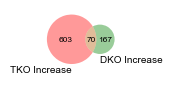

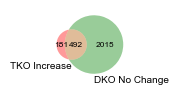

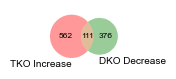

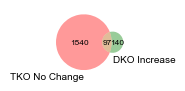

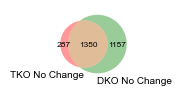

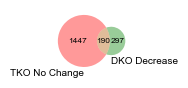

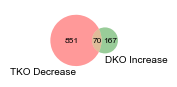

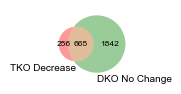

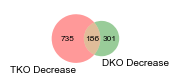

In [60]:
# Venn Diagrams

df_bivalent = df_merged.loc[df_merged['Promoter Class'] == 'Bivalent']
df_k4 = df_merged.loc[df_merged['Promoter Class'] == 'H3K4me3']
df_k27 = df_merged.loc[(df_merged['Promoter Class'] == 'H3K27me3')]

# get combinations of gene groups in TKO and DKO
cat_tko = 'TKO MeanFC Class'
cat_dko = 'DKO MeanFC Class'

df_bivalent_filt = df_bivalent.loc[(df_bivalent[cat_tko] != '0') & (df_bivalent[cat_dko] != '0')]
df_bivalent_filt = df_bivalent_filt.loc[(df_bivalent_filt[cat_tko] != 'nan') & (df_bivalent_filt[cat_dko] != 'nan')]

tko_cats = list(set(df_bivalent_filt[cat_tko]))
dko_cats = list(set(df_bivalent_filt[cat_dko]))

df_bar_records = []

for category_1 in tko_cats:
    
    for category_2 in dko_cats:
        
        a = len(df_bivalent_filt.loc[(df_bivalent_filt[cat_tko] == category_1) & (df_bivalent_filt[cat_dko] == category_2)].index)
        b = len(df_bivalent_filt.loc[(df_bivalent_filt[cat_tko] == category_1) & (df_bivalent_filt[cat_dko] != category_2)].index)
        c = len(df_bivalent_filt.loc[(df_bivalent_filt[cat_tko] != category_1) & (df_bivalent_filt[cat_dko] == category_2)].index)
        d = len(df_bivalent_filt.loc[(df_bivalent_filt[cat_tko] != category_1) & (df_bivalent_filt[cat_dko] != category_2)].index)
        
        p = stats.fisher_exact([[a, c], [b, d]], alternative='two-sided').pvalue

        fig, ax = plt.subplots()
        fig.set_size_inches(1,1)
        venn2(subsets = (b, c, a), set_labels = (f'TKO {category_1}', f'DKO {category_2}'), ax=ax)
        fig.savefig(f'figures/venn_tko_{category_1}_dko_{category_2}.svg')
        plt.show()
    

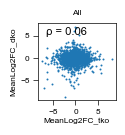

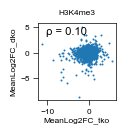

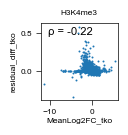

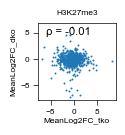

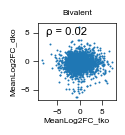

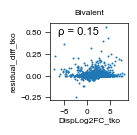

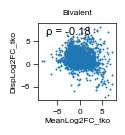

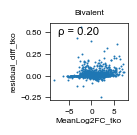

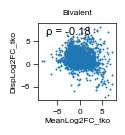

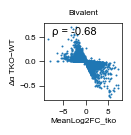

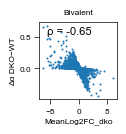

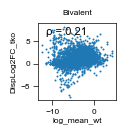

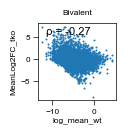

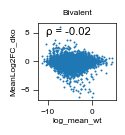

Number of valid TKO Overdispersion Genes: 1296


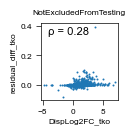

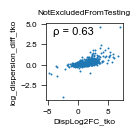

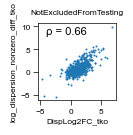

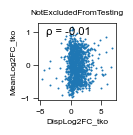

/tmp/ipykernel_3904981/2140622674.py:108: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_plot.dropna(inplace=True)
/tmp/ipykernel_3904981/2140622674.py:109: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_plot.sort_values(by='DispLog2FC_tko', inplace=True)


['LOX', 'HNF1B', 'ATP12A', 'SLCO2A1', 'CLDN5', 'BMPER', 'HLX', 'MOXD1', 'ENTPD3', 'FBLN5']


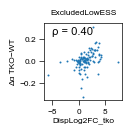

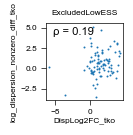

In [53]:
def scatterplot(df, prefix, x, y, xlim=None, ylim=None):

    fig, ax = plt.subplots(figsize=(1,1))
    sns.scatterplot(data=df, x=x, y=y, s=2, linewidth=0, ax=ax)

    if y == 'zero_ratio_wt':
        sns.lineplot(data=df, x=x, y='expected_zero_ratio_wt', ax=ax, color='red')
    elif y == 'zero_ratio_tko':
        sns.lineplot(data=df, x=x, y='expected_zero_ratio_tko', ax=ax, color='red')
    elif y == 'zero_ratio_dko':
        sns.lineplot(data=df, x=x, y='expected_zero_ratio_dko', ax=ax, color='red')

    if y == 'zero_ratio_diff_tko':
        ylabel = 'Δα TKO−WT'
    elif y == 'zero_ratio_diff_dko':
        ylabel = 'Δα DKO−WT'
    else:
        ylabel = y

    plt.title(prefix)

    corrfunc(df[x], df[y])

    #if y == 'residual_diff_tko':
    #    ax.axhline(y=0.02, color='r')
        
    plt.ylabel(ylabel)

    if ylim:
        plt.ylim(ylim)

    fig.savefig(f'figures/scatter_{prefix}_{x}_{y}.svg')
    
    plt.show()

'''
df_plot = df_merged.sample(n=5000)
scatterplot(df_plot, 'All', 'log_mean_wt', 'zero_ratio_wt')
scatterplot(df_plot, 'All', 'log_mean_tko', 'zero_ratio_tko')
scatterplot(df_plot, 'All', 'log_mean_dko', 'zero_ratio_dko')
'''

'''

scatterplot(df_plot, 'All', 'log_mean_wt', 'residual_diff_tko', ylim=[-0.25, 0.55])
scatterplot(df_plot, 'All', 'log_mean_wt_dkonorm', 'residual_diff_dko', ylim=[-0.25, 0.55])

scatterplot(df_plot, 'All', 'MeanLog2FC_tko', 'DispLog2FC_tko')
scatterplot(df_plot, 'All', 'MeanLog2FC_tko', 'residual_diff_tko')
scatterplot(df_plot, 'All', 'DispLog2FC_tko', 'residual_diff_tko')
scatterplot(df_plot, 'All', 'MeanLog2FC_dko', 'residual_diff_dko')

print(f"{'='*60}")

df_exclude = df_bivalent.loc[
    (df_bivalent['TKO MeanFC Class'] == 'No Change')
]

print(f"{'='*60}")

scatterplot(df_plot, 'All', 'MeanLog2FC_tko', 'MeanLog2FC_dko')
scatterplot(df_plot, 'All', 'log_mean_wt', 'residual_zero_ratio_wt')
scatterplot(df_plot, 'All', 'log_mean_tko', 'residual_zero_ratio_tko')

print(f"{'='*60}")
'''

df_plot = df_merged.sample(n=5000)
scatterplot(df_plot, 'All', 'MeanLog2FC_tko', 'MeanLog2FC_dko')

df_k4 = df_merged.loc[df_merged['Promoter Class'] == 'H3K4me3']
scatterplot(df_k4, 'H3K4me3', 'MeanLog2FC_tko', 'MeanLog2FC_dko')
scatterplot(df_k4, 'H3K4me3', 'MeanLog2FC_tko', 'residual_diff_tko')

df_k27 = df_merged.loc[df_merged['Promoter Class'] == 'H3K27me3']
scatterplot(df_k27, 'H3K27me3', 'MeanLog2FC_tko', 'MeanLog2FC_dko')

df_bivalent = df_merged.loc[df_merged['Promoter Class'] == 'Bivalent']
scatterplot(df_bivalent, 'Bivalent', 'MeanLog2FC_tko', 'MeanLog2FC_dko')

scatterplot(df_bivalent, 'Bivalent', 'DispLog2FC_tko', 'residual_diff_tko')

scatterplot(df_bivalent, 'Bivalent', 'MeanLog2FC_tko', 'DispLog2FC_tko')
scatterplot(df_bivalent, 'Bivalent', 'MeanLog2FC_tko', 'residual_diff_tko')

scatterplot(df_bivalent, 'Bivalent', 'MeanLog2FC_tko', 'DispLog2FC_tko')
scatterplot(df_bivalent, 'Bivalent', 'MeanLog2FC_tko', 'zero_ratio_diff_tko')
scatterplot(df_bivalent, 'Bivalent', 'MeanLog2FC_dko', 'zero_ratio_diff_dko')

scatterplot(df_bivalent, 'Bivalent', 'log_mean_wt', 'DispLog2FC_tko')
scatterplot(df_bivalent, 'Bivalent', 'log_mean_wt', 'MeanLog2FC_tko')
scatterplot(df_bivalent, 'Bivalent', 'log_mean_wt', 'MeanLog2FC_dko')

print(f"{'='*60}")

df_exclude = df_bivalent.loc[
    (df_bivalent['ResultDiffDisp_tko'] != 'ExcludedLowESS') & 
    (df_bivalent['ResultDiffDisp_tko'] != 'ExcludedFromTesting')
]
print('Number of valid TKO Overdispersion Genes:', len(df_exclude.index))

scatterplot(df_exclude, 'NotExcludedFromTesting', 'DispLog2FC_tko', 'residual_diff_tko')
scatterplot(df_exclude, 'NotExcludedFromTesting', 'DispLog2FC_tko', 'log_dispersion_diff_tko')
scatterplot(df_exclude, 'NotExcludedFromTesting', 'DispLog2FC_tko', 'log_dispersion_nonzero_diff_tko')
scatterplot(df_exclude, 'NotExcludedFromTesting', 'DispLog2FC_tko', 'MeanLog2FC_tko')

df_plot = df_exclude[['DispLog2FC_tko', 'zero_ratio_diff_tko', 'ResultDiffDisp_tko']]
df_plot.dropna(inplace=True)
df_plot.sort_values(by='DispLog2FC_tko', inplace=True)
print(list(df_plot.tail(10).index))

print(f"{'='*60}")

df_plot = df_bivalent.loc[(df_bivalent['ResultDiffDisp_tko'] == 'ExcludedLowESS')]
scatterplot(df_plot, 'ExcludedLowESS', 'DispLog2FC_tko', 'zero_ratio_diff_tko')
scatterplot(df_plot, 'ExcludedLowESS', 'DispLog2FC_tko', 'log_dispersion_nonzero_diff_tko')

#scatterplot(df_bivalent, 'log_dispersion_diff_tko', 'log_dispersion_nonzero_diff_tko')
#scatterplot(df_bivalent, 'zero_ratio_diff_tko', 'log_dispersion_nonzero_diff_tko')


DKO % Bivalent genes < -0.1: 0.05704898446833931
DKO % H3K4me3 genes < -0.1: 0.0352848928384736
DKO % H3K27me3 genes < -0.1: 0.04372093023255814
DKO % Bivalent genes > 0.1: 0.05675029868578255
DKO % H3K4me3 genes > 0.1: 0.04939884997386304
DKO % H3K27me3 genes > 0.1: 0.04744186046511628


/tmp/ipykernel_1869510/3735240631.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filt.dropna(inplace=True)


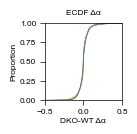

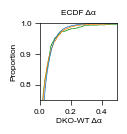

In [31]:
x='MeanLog2FC_tko'
xlim=0.1

###############

df_filt = df_merged[[x, 'Promoter Class']]
df_filt.dropna(inplace=True)

df_bivalent = df_filt.loc[df_filt['Promoter Class'] == 'Bivalent']
df_k4 = df_filt.loc[df_filt['Promoter Class'] == 'H3K4me3']
df_k27 = df_filt.loc[df_filt['Promoter Class'] == 'H3K27me3']

print('DKO % Bivalent genes < -0.1:', len(df_bivalent.loc[df_bivalent[x] < -xlim].index)/len(df_bivalent.index))
print('DKO % H3K4me3 genes < -0.1:', len(df_k4.loc[df_k4[x] < -xlim].index)/len(df_k4.index))
print('DKO % H3K27me3 genes < -0.1:', len(df_k27.loc[df_k27[x] < -xlim].index)/len(df_k27.index))

print('DKO % Bivalent genes > 0.1:', len(df_bivalent.loc[df_bivalent[x] > xlim].index)/len(df_bivalent.index))
print('DKO % H3K4me3 genes > 0.1:', len(df_k4.loc[df_k4[x] > xlim].index)/len(df_k4.index))
print('DKO % H3K27me3 genes > 0.1:', len(df_k27.loc[df_k27[x] > xlim].index)/len(df_k27.index))

In [46]:
x='residual_diff_tko'
lim = 0.02

###############

df_filt = df_merged[[x, 'Promoter Class']]
df_filt.dropna(inplace=True)

df_bivalent = df_filt.loc[df_filt['Promoter Class'] == 'Bivalent']
df_k4 = df_filt.loc[df_filt['Promoter Class'] == 'H3K4me3']
df_k27 = df_filt.loc[df_filt['Promoter Class'] == 'H3K27me3']

print(f'TKO % Bivalent genes < -{lim}:', len(df_bivalent.loc[df_bivalent[x] < -lim].index)/len(df_bivalent.index))
print(f'TKO % H3K4me3 genes < -{lim}:', len(df_k4.loc[df_k4[x] < -lim].index)/len(df_k4.index))
print(f'TKO % H3K27me3 genes < -{lim}:', len(df_k27.loc[df_k27[x] < -lim].index)/len(df_k27.index))

print(f'TKO % Bivalent genes > {lim}:', len(df_bivalent.loc[df_bivalent[x] > lim].index)/len(df_bivalent.index))
print(f'TKO % H3K4me3 genes > {lim}:', len(df_k4.loc[df_k4[x] > lim].index)/len(df_k4.index))
print(f'TKO % H3K27me3 genes > {lim}:', len(df_k27.loc[df_k27[x] > lim].index)/len(df_k27.index))

           residual_diff_tko Promoter Class
TUBA1C              0.145014        H3K4me3
FKBP1B              0.147124        H3K4me3
RBPMS2              0.152037        H3K4me3
JARID2              0.152540        H3K4me3
BST2                0.156213        H3K4me3
C9orf135            0.157318        H3K4me3
APOE                0.160047        H3K4me3
PHC1                0.171452        H3K4me3
MYL9                0.178901        H3K4me3
CTSC                0.183934        H3K4me3
COMTD1              0.184055        H3K4me3
CLU                 0.185176        H3K4me3
USP44               0.186692        H3K4me3
FGF2                0.189328        H3K4me3
COL1A2              0.191377        H3K4me3
OCIAD2              0.191839        H3K4me3
TNFRSF12A           0.199637        H3K4me3
UGP2                0.200016        H3K4me3
GCHFR               0.200637        H3K4me3
APOC1               0.208871        H3K4me3
ZFP42               0.212735        H3K4me3
SPINT1              0.215477    

/tmp/ipykernel_3904981/616861271.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filt.dropna(inplace=True)
/tmp/ipykernel_3904981/616861271.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_k4.sort_values(by=x, inplace=True)


/tmp/ipykernel_3904981/1648893815.py:12: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


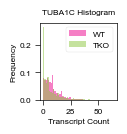

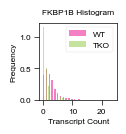

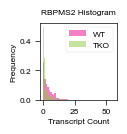

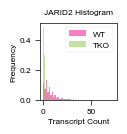

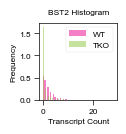

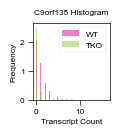

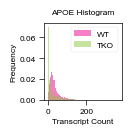

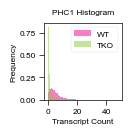

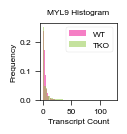

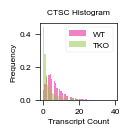

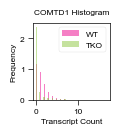

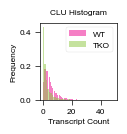

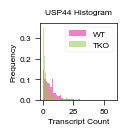

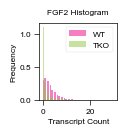

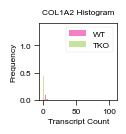

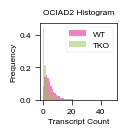

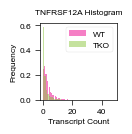

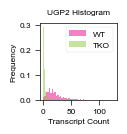

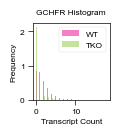

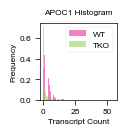

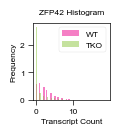

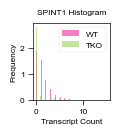

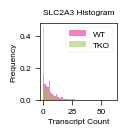

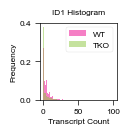

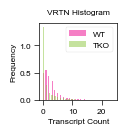

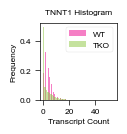

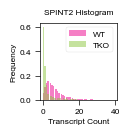

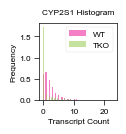

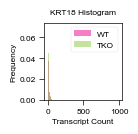

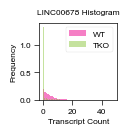

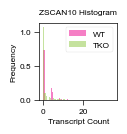

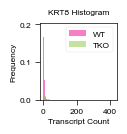

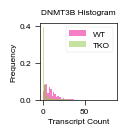

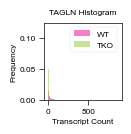

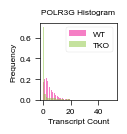

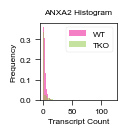

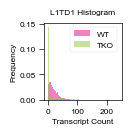

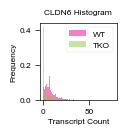

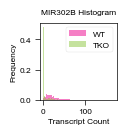

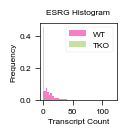

In [47]:
# Gene Histogram Plotting

genes_of_interest = ['NR2F2', 'METRNL']

path_out_dir = 'figures'

colors = ['#ec008c', '#23baaa', '#8dc63f']
colors_tko = ['#ec008c', '#8dc63f']

for gene in genes_of_interest:
    
    fig, ax = plt.subplots()
    fig.set_size_inches(1, 1)
    #bins = np.linspace(0, 5, 6)
    bins=None

    for i, df in enumerate(dfs_tko):
        
        name = names_tko[i]
        counts = df[gene]
        
        ax.hist(counts, bins=50, alpha = 0.5, color=colors_tko[i], label=name, density=True)

    #ax.set_xlim([0, 20])

    plt.legend()
    plt.title(f'{gene} Histogram')
    plt.ylabel('Frequency')
    plt.xlabel('Transcript Count')
    fig.savefig(os.path.join(path_out_dir, f'hist_{gene}_tko.svg'))
        